# Library

In [1]:
import pandas as pd
import numpy as np
from IPython.display import clear_output
import matplotlib.pyplot as plt
from classes import *
import os
os.chdir(r'c:\\Users\\arvin\\Documents\\Coding Project\\V4\\Algotrading_RL\\src')
from utils.utils import CreateTimeFrames

# Data

In [2]:
#os.getcwd()
os.chdir(r'c:\\Users\\arvin\\Documents\\Coding Project\\V4\\Algotrading_RL\\src\\data')
#os.getcwd()
df = pd.read_csv('BTCUSD_1m_2024-09-23.csv', index_col='time', usecols=['time', 'open', 'high', 'low', 'close', 'tick_volume'])
df.index = pd.to_datetime(df.index)

os.chdir(r'c:\\Users\\arvin\\Documents\\Coding Project\\V4\\Algotrading_RL\\src\\brute_force')

price_column = 'open'
date_split = "2024-10-1"
tf = '1d'

timeframes = ['1min','5min','15min', '30min','1h', '4h','1d','1w','1m']
df = CreateTimeFrames(df,timeframes)

working_dataset = df[tf]

df_train = working_dataset[:date_split]
df_test = working_dataset[date_split:]

price_type = 'smoothed_data'
trade_price = 'open'

clear_output()

# Anlyzer

In [16]:
class MACDBacktester:
    def __init__(self, data, fast_ema, slow_ema, signal_line, signal_price = 'close', real_price = 'close',
                  sell_fee = 0.115, buy_fee = 0.115, initial_capital = 100):
        self.data = data.copy()
        self.fast_ema = fast_ema
        self.slow_ema = slow_ema
        self.signal_line = signal_line
        self.signal_price = signal_price
        self.real_price = real_price
        self.sell_fee_percent = sell_fee / 100
        self.buy_fee_percent = buy_fee / 100
        self.initial_capital = initial_capital
        self.trades = []
        self.data['positions'] = 0
        
    def calculate_macd(self):
        self.data['fast_ema'] = self.data[self.signal_price].ewm(span = self.fast_ema, adjust = False).mean()
        self.data['slow_ema'] = self.data[self.signal_price].ewm(span = self.slow_ema, adjust = False).mean()
        self.data['macd_line'] = self.data['fast_ema'] - self.data['slow_ema']
        self.data['signal_line'] = self.data['macd_line'].ewm(span = self.signal_line, adjust = False).mean()


    def generate_signals(self):
        """
        Generates trading signals based on MACD crossover.
        """
        threshold = 0.1
        self.data['signal'] = 0
        self.data['signal'] = np.where((self.data['macd_line'] - self.data['signal_line']) > threshold, 1, 0) # Buy signal
        self.data['signal'] = np.where((self.data['macd_line'] - self.data['signal_line']) < -threshold, 0, self.data['signal']) # Sell signal
        # Generation the position by shifting the signals
        #self.data['positions'] = self.data['signal'].shift(1).fillna(0)
        self.data['positions'] = self.data['signal']
        return self.data

    def backtest_strategy(self):
        """
        Backtests the strategy and calculates performance metrics.
        """
        self.data['price'] = self.data[self.real_price]
        self.data['positions'] = self.data['positions'].astype(int)
        self.data['positions_diff'] = self.data['positions'].diff()
        self.data['positions_diff'].fillna(0)

        # Initialize cash and holdings
        self.data['cash'] = self.initial_capital
        self.data['holdings'] = 0.0
        self.data['total'] = self.initial_capital


        # Variable to keep track of cash, holdings, trades
        cash = self.initial_capital
        holdings = 0.0
        position = 0  # Current position (number of shares)
        buy_price = 0.0
        win_count = 0  # Win rate calculation
        total_trades = 0

        for idx, row in self.data.iterrows():
            position_change = row['positions_diff']
            price = row['price']
            if position_change == 1: # Long position
                # With regard to the randomness of market, I can decide how much of cash should spend for trading.
                shares_to_buy = round(cash/(price),8)
                shares_to_buy = shares_to_buy * (1-self.buy_fee_percent)

                if shares_to_buy > 0.00002:
                    buy_price = round((cash/shares_to_buy),8) 
                    total_cost = round(shares_to_buy * buy_price, 8)
                    cash -= total_cost
                    holdings += shares_to_buy * price
                    position += shares_to_buy


            elif position_change ==-1 and position > 0: # position is the number of shares.
                # Exit the long position
                sell_price = price * (1-self.sell_fee_percent)
                total_proceeds = position * sell_price
                cash += total_proceeds
                holdings -= position * sell_price
                # Calculate trade return
                trade_return = (sell_price - buy_price)/buy_price * 100
                self.trades.append(trade_return)
                position = 0
                total_trades +=1 # Win rate calculation
                if trade_return>0:
                    win_count +=1
            else:
                # Hold position
                holdings = position * price


            total = cash + holdings
            self.data.at[idx, 'cash'] = float(cash)
            self.data.at[idx, 'holdings'] = holdings
            self.data.at[idx, 'total'] = float(total)

        if position > 0 :
            
            price = self.data.iloc[-1]['price']
            sell_price = price * (1-self.sell_fee_percent)
            total_proceeds = position * sell_price
            cash += total_proceeds
            # Calculate trade return
            trade_return = (sell_price - buy_price) / buy_price * 100
            self.trades.append(trade_return)
            position = 0
            total_trades +=1 # Win rate calculation
            if trade_return>0:
                win_count +=1
            total = cash + holdings
            self.data.at[self.data.index[-1], 'cash'] = cash
            self.data.at[self.data.index[-1], 'holdings'] = holdings
            self.data.at[self.data.index[-1], 'total'] = total

        self.results = self.data[['cash', 'holdings', 'total']]
        self.results = self.data[['cash', 'holdings', 'total']]

        self.win_rate = (win_count / total_trades * 100) if total_trades > 0 else 0
        return self.data

    def get_performance_metrics(self):
        """
        Calculates and returns performance metrics.
        """
        if self.results is None:
            print("Please run backtest_strategy() before calculating performance metrics.")
            return None

        total_return = (self.results['total'].iloc[-1] - self.initial_capital) / self.initial_capital * 100
        returns = self.results['total'].pct_change().fillna(0)
        annualized_return = ((1 + returns.mean()) ** 252 - 1) * 100  # Assuming daily returns
        annualized_volatility = returns.std() * np.sqrt(252) * 100
        sharpe_ratio = (returns.mean() / returns.std()) * np.sqrt(252) if returns.std() != 0 else np.nan
        max_drawdown = ((self.results['total'].cummax() - self.results['total']) / self.results['total'].cummax()).max() * 100

        metrics = {
            'Total Return (%)': total_return,
            'Annualized Return (%)': annualized_return,
            'Annualized Volatility (%)': annualized_volatility,
            'Sharpe Ratio': sharpe_ratio,
            'Max Drawdown (%)': max_drawdown,
            'Win Rate (%)' : self.win_rate
        }
        return metrics

    def print_trades(self):
        """
        Prints individual trade returns.
        """
        if not self.trades:
            print("No trades have been executed.")
            return
        for idx, trade_return in enumerate(self.trades, 1):
            print(f"Trade {idx}: Return = {trade_return:.2f}%")
        total_return = sum(self.trades)
        print(f"Total Return from trades: {total_return:.2f}%")


In [17]:
backtester = MACDBacktester(df_train, 7, 22, 8,signal_price='open', real_price='open')
backtester.calculate_macd()
backtester.generate_signals()
ali = backtester.backtest_strategy()
metrics = backtester.get_performance_metrics()
print(metrics)
backtester.print_trades()


position is :0.0016032841005
is runing
sell price is 63736.6085115
holdings is 0.11765137378306179
buy price is 57634.33950436
trade return is 10.587904814417742
{'Total Return (%)': 2.30554242022329, 'Annualized Return (%)': 11.707078186917208, 'Annualized Volatility (%)': 27.443096582297084, 'Sharpe Ratio': 0.40350478652789823, 'Max Drawdown (%)': 12.99879813567241, 'Win Rate (%)': 20.0}
Trade 1: Return = -0.45%
Trade 2: Return = -2.67%
Trade 3: Return = -2.08%
Trade 4: Return = -2.61%
Trade 5: Return = 10.59%
Total Return from trades: 2.78%


C:\Users\arvin\AppData\Local\Temp\ipykernel_17748\3600107888.py:96: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '99.88518690231487' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  self.data.at[idx, 'total'] = float(total)
C:\Users\arvin\AppData\Local\Temp\ipykernel_17748\3600107888.py:94: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '99.55194148077038' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  self.data.at[idx, 'cash'] = float(cash)


In [5]:
ali

,open,high,low,close,tick_volume,positions,fast_ema,slow_ema,macd_line,signal_line,signal,price,positions_diff,cash,holdings,total
2024-07-16,64585.70,65199.99,62379.79,64651.81,57847.0,0,64585.700000,64585.700000,0.000000,0.000000,0,64585.70,NaN,1.000000e+02,0.000000,100.000000
2024-07-17,64651.81,66113.75,63854.00,64510.30,53665.0,1,64602.227500,64591.448696,10.778804,2.395290,1,64651.81,1.0,0.000000e+00,99.885187,99.885187
2024-07-18,64510.30,65126.61,63238.48,63826.00,41108.0,0,64579.245625,64584.392287,-5.146662,0.719300,0,64510.30,-1.0,9.955194e+01,0.333245,99.885187
2024-07-19,63826.00,67385.99,63300.67,66931.80,46197.0,0,64390.934219,64518.445132,-127.510913,-27.776303,0,63826.00,0.0,9.955194e+01,0.000000,99.551941
2024-07-20,66931.80,67597.99,66222.46,67339.27,18955.0,1,65026.150664,64728.302077,297.848587,44.584784,1,66931.80,1.0,7.703846e-10,99.437198,99.437198
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-09-27,64664.26,66487.17,64633.52,65804.87,40048.0,1,63351.313649,61245.826664,2105.486985,1615.045353,1,64664.26,0.0,1.593037e-10,103.675180,103.675180
2024-09-28,65804.87,66259.99,65422.23,65645.99,12603.0,1,63964.702737,61642.265215,2322.437522,1772.243613,1,65804.87,0.0,1.593037e-10,105.503902,105.503902
2024-09-29,65645.99,66076.11,65432.00,65812.00,11735.0,1,64385.024553,61990.415196,2394.609356,1910.547111,1,65645.99,0.0,1.593037e-10,105.249172,105.249172
2024-09-30,65812.00,65973.15,63056.00,63809.99,45560.0,1,64741.768414,62322.726918,2419.041496,2023.545863,1,65812.00,0.0,1.593037e-10,105.515333,105.515333


In [6]:
class MACDBacktester:
    def __init__(self, data, fast_ema, slow_ema, signal_line, signal_price = 'close', real_price = 'close',
                  sell_fee = 0.115, buy_fee = 0.115, initial_capital = 100):
        self.data = data.copy()
        self.fast_ema = fast_ema
        self.slow_ema = slow_ema
        self.signal_line = signal_line
        self.signal_price = signal_price
        self.real_price = real_price
        self.sell_fee_percent = sell_fee / 100
        self.buy_fee_percent = buy_fee / 100
        self.initial_capital = initial_capital
        self.trades = []
        self.data['positions'] = 0
        
    def calculate_macd(self):
        self.data['fast_ema'] = self.data[self.signal_price].ewm(span = self.fast_ema, adjust = False).mean()
        self.data['slow_ema'] = self.data[self.signal_price].ewm(span = self.slow_ema, adjust = False).mean()
        self.data['macd_line'] = self.data['fast_ema'] - self.data['slow_ema']
        self.data['signal_line'] = self.data['macd_line'].ewm(span = self.signal_line, adjust = False).mean()


    def generate_signals(self):
        """
        Generates trading signals based on MACD crossover.
        """
        threshold = 0.02
        self.data['signal'] = 0
        self.data['signal'] = np.where((self.data['macd_line'] - self.data['signal_line']) > threshold, 1, 0) # Buy signal
        self.data['signal'] = np.where((self.data['macd_line'] - self.data['signal_line']) < -threshold, 0, self.data['signal']) # Sell signal
        # Generation the position by shifting the signals
        #self.data['positions'] = self.data['signal'].shift(1).fillna(0)
        self.data['positions'] = self.data['signal']

    def backtest_strategy(self):
        """
        Backtests the strategy and calculates performance metrics.
        """
        self.data['price'] = self.data[self.real_price]
        self.data['positions'] = self.data['positions'].astype(int)
        self.data['positions_diff'] = self.data['positions'].diff()
        self.data['positions_diff'].fillna(0, inplace = True)

        # Initialize cash and holdings
        self.data['cash'] = self.initial_capital
        self.data['holdings'] = 0.0
        self.data['total'] = self.initial_capital


        # Variable to keep track of cash, holdings, trades
        cash = self.initial_capital
        holdings = 0.0
        position = 0  # Current position (number of shares)
        buy_price = 0.0

        for idx, row in self.data.iterrows():
            position_change = row['positions_diff']
            price = row['price']
            if position_change == 1: # Long position
                # With regard to the randomness of market, I can decide how much of cash should spend for trading.
                shares_to_buy = round(cash/(price),8)
                shares_to_buy = shares_to_buy * (1-self.buy_fee_percent)

                if shares_to_buy > 0.00002:
                    buy_price = round((cash/shares_to_buy),8) 
                    total_cost = round(shares_to_buy * buy_price, 8)
                    cash -= total_cost
                    holdings += shares_to_buy * price
                    position += shares_to_buy


            elif position_change ==-1 and position > 0: # position is the number of shares.
                # Exit the long position
                sell_price = price * (1-self.buy_fee_percent)
                total_proceeds = position * sell_price
                cash += total_proceeds
                holdings -= position * sell_price
                # Calculate trade return
                trade_return = (sell_price - buy_price)/buy_price * 100
                self.trades.append(trade_return)
                position = 0
            else:
                # Hold position
                holdings = position * price


            total = cash + holdings
            self.data.at[idx, 'cash'] = cash
            self.data.at[idx, 'holdings'] = holdings
            self.data.at[idx, 'total'] = total

        if position > 0 :
            price = self.data.iloc[-1]['price']
            sell_price = sell_price = price * shares_to_buy * (1-self.buy_fee_percent)
            total_proceeds = position * sell_price
            cash += total_proceeds
            holdings -= position * sell_price
            # Calculate trade return
            trade_return = (sell_price - buy_price) / buy_price * 100
            self.trades.append(trade_return)
            position = 0
            total = cash + holdings
            self.data.at[self.data.index[-1], 'cash'] = cash
            self.data.at[self.data.index[-1], 'holdings'] = holdings
            self.data.at[self.data.index[-1], 'total'] = total

        self.results = self.data[['cash', 'holdings', 'total']]

        return self.data

In [7]:
backtester = MACDBacktester(df_train, 3, 5, 7)
backtester.calculate_macd()
backtester.generate_signals()
data = backtester.backtest_strategy()
data = data.drop(data.index[0])
data.head(n=10)

C:\Users\arvin\AppData\Local\Temp\ipykernel_17748\1534772052.py:42: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  self.data['positions_diff'].fillna(0, inplace = True)
C:\Users\arvin\AppData\Local\Temp\ipykernel_17748\1534772052.py:90: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '99.88512496412581' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  self.data.at[idx, 'total'] = total
C:\Users\arvin\AppData\L

,open,high,low,close,tick_volume,positions,fast_ema,slow_ema,macd_line,signal_line,signal,price,positions_diff,cash,holdings,total
2024-07-17,64651.81,66113.75,63854.00,64510.30,53665.0,0,64581.055000,64604.640000,-23.585000,-5.896250,0,64510.30,0.0,1.000000e+02,0.000000,100.000000
2024-07-18,64510.30,65126.61,63238.48,63826.00,41108.0,0,64203.527500,64345.093333,-141.565833,-39.813646,0,63826.00,0.0,1.000000e+02,0.000000,100.000000
2024-07-19,63826.00,67385.99,63300.67,66931.80,46197.0,1,65567.663750,65207.328889,360.334861,60.223481,1,66931.80,1.0,0.000000e+00,99.885125,99.885125
2024-07-20,66931.80,67597.99,66222.46,67339.27,18955.0,1,66453.466875,65917.975926,535.490949,179.040348,1,67339.27,0.0,0.000000e+00,100.493209,100.493209
2024-07-21,67339.27,68209.15,65777.00,67723.90,35025.0,1,67088.683438,66519.950617,568.732820,276.463466,1,67723.90,0.0,0.000000e+00,101.067209,101.067209
2024-07-22,67723.90,68474.54,66559.99,68123.99,41458.0,1,67606.336719,67054.630412,551.706307,345.274176,1,68123.99,0.0,0.000000e+00,101.664280,101.664280
2024-07-23,68123.99,68166.00,65441.29,65836.00,55486.0,0,66721.168359,66648.420274,72.748085,277.142653,0,65836.00,-1.0,9.813683e+01,3.527450,101.664280
2024-07-24,65836.00,67102.00,65476.84,66044.00,35240.0,0,66382.584180,66446.946850,-64.362670,191.766323,0,66044.00,0.0,9.813683e+01,0.000000,98.136829
2024-07-25,66044.00,66066.65,63456.70,65298.00,55770.0,0,65840.292090,66063.964566,-223.672477,87.906623,0,65298.00,0.0,9.813683e+01,0.000000,98.136829
2024-07-26,65298.00,68144.00,65214.00,67435.16,38305.0,1,66637.726045,66521.029711,116.696334,95.104051,1,67435.16,1.0,-3.587573e-09,98.024182,98.024182


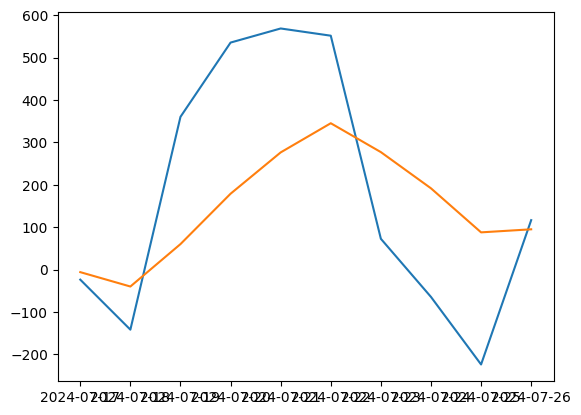

In [8]:
plt.plot(data['macd_line'][:10], label = 'MACD line')
plt.plot(data['signal_line'][:10], label = 'Signal line')

In [9]:
backtester = MACDBacktester(df_train, 3, 5, 7)
backtester.calculate_macd()
backtester.generate_signals()
backtester.backtest_strategy()
metrics = backtester.get_performance_metrics()
print(metrics)
backtester.print_trades()


C:\Users\arvin\AppData\Local\Temp\ipykernel_17748\1534772052.py:42: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  self.data['positions_diff'].fillna(0, inplace = True)
C:\Users\arvin\AppData\Local\Temp\ipykernel_17748\1534772052.py:90: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '99.88512496412581' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  self.data.at[idx, 'total'] = total
C:\Users\arvin\AppData\L

AttributeError: 'MACDBacktester' object has no attribute 'get_performance_metrics'

In [ ]:
i = 0
for idx, row in working_dataset.iterrows():
    position_change = row['close']
    print(position_change)

